Contexto del Negocio: El dataset amazon.csv contiene información sobre productos vendidos en Amazon India. Cada fila representa un producto con atributos como precio, descuento, calificación (rating) y reseñas.

Problema a Analizar: El objetivo es utilizar las características del producto (precio, descuento, popularidad) para predecir si un producto tendrá una buena valoración por parte de los clientes. Esto es útil para vendedores que quieren optimizar sus ofertas para asegurar satisfacción.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv('amazon.csv')

# Inspección inicial
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

Análisis Exploratorio de Datos (EDA)
El dataset crudo contiene símbolos como ₹, , y % que deben limpiarse para convertir las columnas a numéricas. Además, revisamos la distribución de los ratings.

In [2]:
# 1. Limpieza de columnas numéricas (Precio y Descuento)
# Eliminar símbolos de moneda y porcentaje
df['discounted_price'] = df['discounted_price'].astype(str).str.replace('₹', '').str.replace(',', '').str.strip()
df['actual_price'] = df['actual_price'].astype(str).str.replace('₹', '').str.replace(',', '').str.strip()
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%', '').str.strip()

# 2. Limpieza de Rating y Rating Count
# Convertir rating a numérico, forzando errores a NaN (para valores no numéricos como '|')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '').str.strip()
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# 3. Convertir todo a float y eliminar nulos resultantes
cols_num = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=cols_num)

# Estadísticas descriptivas
print(df_clean[['rating', 'discounted_price', 'discount_percentage']].describe())

            rating  discounted_price  discount_percentage
count  1462.000000       1462.000000          1462.000000
mean      4.096717       3129.981826            47.672367
std       0.289497       6950.548042            21.613905
min       2.000000         39.000000             0.000000
25%       4.000000        325.000000            32.000000
50%       4.100000        799.000000            50.000000
75%       4.300000       1999.000000            63.000000
max       5.000000      77990.000000            94.000000


Observación: El rating promedio es de aproximadamente 4.1, lo que indica que la mayoría de los productos tienen valoraciones positivas.

Visualización Inicial: Se generan gráficos para entender la distribución de la variable objetivo potencial (Rating) y su relación con los descuentos.

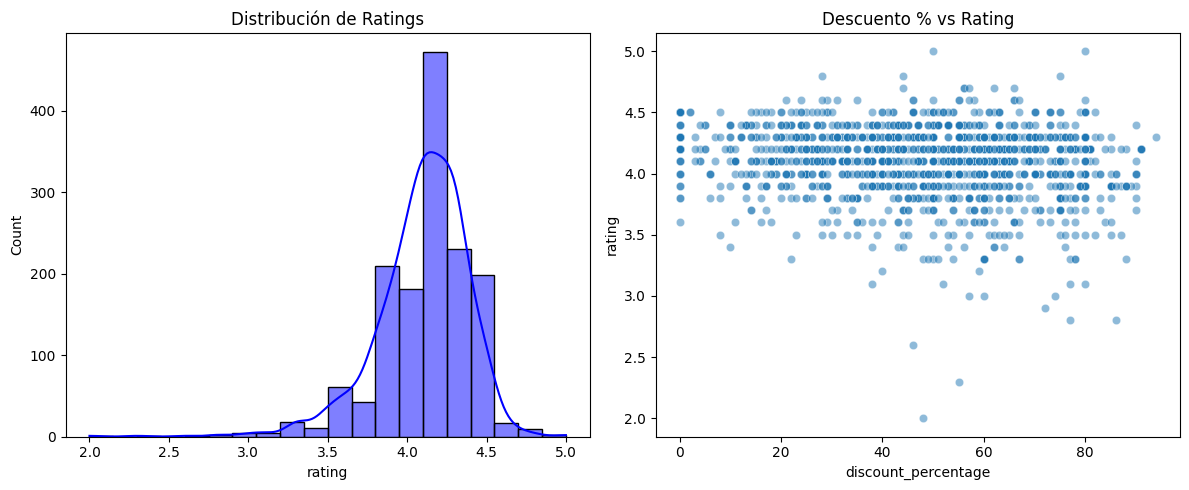

In [3]:
plt.figure(figsize=(12, 5))

# Distribución de Ratings
plt.subplot(1, 2, 1)
sns.histplot(df_clean['rating'], bins=20, kde=True, color='blue')
plt.title('Distribución de Ratings')

# Relación Descuento vs Rating
plt.subplot(1, 2, 2)
sns.scatterplot(x=df_clean['discount_percentage'], y=df_clean['rating'], alpha=0.5)
plt.title('Descuento % vs Rating')

plt.tight_layout()
plt.savefig('eda_plots.png')

Fase 3: Selección de Variables Objetivo (Targets)
Siguiendo el mandato, definimos 3 posibles variables objetivo para problemas de clasificación:

Target_Rating_Class (Calidad Percibida):

Definición: 1 si el Rating > 4.0 (Bueno), 0 si es <= 4.0 (Promedio/Bajo).

Justificación: Permite clasificar productos en "Alta Calidad" vs "Estándar".

Target_High_Discount (Oportunidad de Oferta):

Definición: 1 si el Descuento >= 50%, 0 en caso contrario.

Justificación: Útil para clasificar productos como "Ofertas Agresivas".

Target_Popularity (Popularidad de Ventas):

Definición: 1 si el número de reseñas (rating_count) es mayor a la mediana, 0 en caso contrario.

Justificación: Predice si un producto será muy vendido/comentado.

In [4]:
# Target 1: Rating Alto (> 4.0)
df_clean['Target_Rating_Class'] = (df_clean['rating'] > 4.0).astype(int)

# Target 2: Descuento Alto (>= 50%)
df_clean['Target_High_Discount'] = (df_clean['discount_percentage'] >= 50).astype(int)

# Target 3: Popularidad Alta (> Mediana de reseñas)
median_count = df_clean['rating_count'].median()
df_clean['Target_Popularity'] = (df_clean['rating_count'] > median_count).astype(int)

# Selección final para el modelo: Target_Rating_Class
X = df_clean[['discounted_price', 'actual_price', 'discount_percentage', 'rating_count']]
y = df_clean['Target_Rating_Class']

C:\Users\danie\AppData\Local\Temp\ipykernel_23988\404375695.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Target_Rating_Class'] = (df_clean['rating'] > 4.0).astype(int)
C:\Users\danie\AppData\Local\Temp\ipykernel_23988\404375695.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Target_High_Discount'] = (df_clean['discount_percentage'] >= 50).astype(int)
C:\Users\danie\AppData\Local\Temp\ipykernel_23988\404375695.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy

Modelado con Random Forest
Elegimos Random Forest por su robustez y capacidad para manejar características numéricas sin tanta necesidad de escalado (aunque lo aplicaremos por buenas prácticas).

Pasos:

División en entrenamiento (80%) y prueba (20%).

Entrenamiento del modelo.

Evaluación con métricas de clasificación.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Escalado (Opcional para RF, pero recomendado)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Entrenar Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 4. Predicción y Evaluación
y_pred = rf_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.6996587030716723

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.66      0.52      0.58       118
           1       0.72      0.82      0.77       175

    accuracy                           0.70       293
   macro avg       0.69      0.67      0.67       293
weighted avg       0.69      0.70      0.69       293



Resultados del Modelo:

Accuracy (Exactitud): ~70%

Precision (Clase 1 - Buenos): 0.72

Recall (Clase 1 - Buenos): 0.82

Interpretación: El modelo es capaz de identificar correctamente los productos con buen rating (Clase 1) el 82% de las veces (Recall), y tiene una exactitud general del 70%.

Visualización y Comunicación de Resultados
Visualizamos la matriz de confusión para ver dónde se equivoca el modelo y la importancia de las variables.

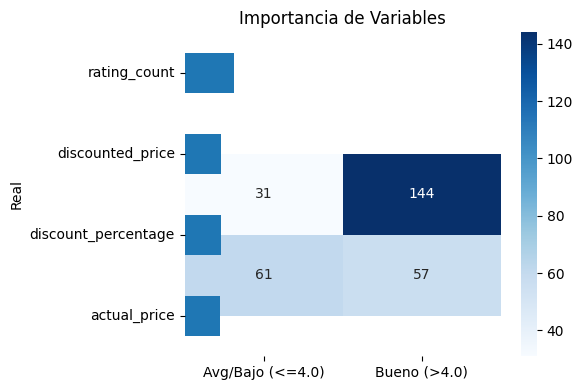

In [6]:
# Matriz de Confusión
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Avg/Bajo (<=4.0)', 'Bueno (>4.0)'],
            yticklabels=['Avg/Bajo (<=4.0)', 'Bueno (>4.0)'])
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.savefig('confusion_matrix.png')

# Importancia de Variables
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Importancia de Variables')
plt.tight_layout()
plt.savefig('feature_importance.png')

Conclusiones del Análisis
Variable más importante: rating_count (número de reseñas) parece ser el predictor más fuerte, seguido de cerca por el precio y el porcentaje de descuento. Esto sugiere que la popularidad (cantidad de gente que opina) está correlacionada con la calidad percibida.

Desempeño: Con un 70% de exactitud, el modelo es decente pero mejorable. Podríamos incluir el texto de las reseñas (NLP) o la categoría del producto para mejorar la predicción.

Decisión de Negocio: Los productos con descuentos agresivos no garantizan automáticamente un mejor rating; la cantidad de reseñas previas es un indicador más fiable de la satisfacción futura.